In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
import re

log_data_only_gru = """
epoch=1 train_loss=0.007476 val_loss=0.010219 lr=0.00100000 best_val=0.010219
epoch=2 train_loss=0.005497 val_loss=0.010387 lr=0.00100000 best_val=0.010219
epoch=3 train_loss=0.005156 val_loss=0.010531 lr=0.00100000 best_val=0.010219
epoch=4 train_loss=0.004952 val_loss=0.010665 lr=0.00100000 best_val=0.010219
epoch=5 train_loss=0.004768 val_loss=0.010778 lr=0.00100000 best_val=0.010219
epoch=6 train_loss=0.004630 val_loss=0.010698 lr=0.00100000 best_val=0.010219
epoch=7 train_loss=0.004487 val_loss=0.010418 lr=0.00050000 best_val=0.010219
epoch=8 train_loss=0.004195 val_loss=0.009963 lr=0.00050000 best_val=0.009963
epoch=9 train_loss=0.004145 val_loss=0.009952 lr=0.00050000 best_val=0.009952
epoch=10 train_loss=0.004095 val_loss=0.010006 lr=0.00050000 best_val=0.009952
epoch=11 train_loss=0.004048 val_loss=0.009993 lr=0.00050000 best_val=0.009952
epoch=12 train_loss=0.004012 val_loss=0.009877 lr=0.00050000 best_val=0.009877
epoch=13 train_loss=0.003975 val_loss=0.009922 lr=0.00050000 best_val=0.009877
epoch=14 train_loss=0.003931 val_loss=0.009724 lr=0.00050000 best_val=0.009724
epoch=15 train_loss=0.003907 val_loss=0.009639 lr=0.00050000 best_val=0.009639
epoch=16 train_loss=0.003872 val_loss=0.009752 lr=0.00050000 best_val=0.009639
epoch=17 train_loss=0.003845 val_loss=0.009911 lr=0.00050000 best_val=0.009639
epoch=18 train_loss=0.003819 val_loss=0.009618 lr=0.00050000 best_val=0.009618
epoch=19 train_loss=0.003798 val_loss=0.009568 lr=0.00050000 best_val=0.009568
epoch=20 train_loss=0.003779 val_loss=0.009575 lr=0.00050000 best_val=0.009568
epoch=21 train_loss=0.003755 val_loss=0.009544 lr=0.00050000 best_val=0.009544
epoch=22 train_loss=0.003738 val_loss=0.009495 lr=0.00050000 best_val=0.009495
epoch=23 train_loss=0.003717 val_loss=0.009583 lr=0.00050000 best_val=0.009495
epoch=24 train_loss=0.003700 val_loss=0.009700 lr=0.00050000 best_val=0.009495
epoch=25 train_loss=0.003680 val_loss=0.009522 lr=0.00050000 best_val=0.009495
"""

only_attention = """
epoch=1 train_loss=0.007558 val_loss=0.008465 lr=0.00100000 best_val=0.008465
epoch=2 train_loss=0.005649 val_loss=0.007854 lr=0.00100000 best_val=0.007854
epoch=3 train_loss=0.005364 val_loss=0.007583 lr=0.00100000 best_val=0.007583
epoch=4 train_loss=0.005231 val_loss=0.007295 lr=0.00100000 best_val=0.007295
epoch=5 train_loss=0.005143 val_loss=0.007220 lr=0.00100000 best_val=0.007220
epoch=6 train_loss=0.005078 val_loss=0.007224 lr=0.00100000 best_val=0.007220
epoch=7 train_loss=0.005017 val_loss=0.007100 lr=0.00100000 best_val=0.007100
epoch=8 train_loss=0.004961 val_loss=0.007052 lr=0.00100000 best_val=0.007052
epoch=9 train_loss=0.004910 val_loss=0.006930 lr=0.00100000 best_val=0.006930
epoch=10 train_loss=0.004846 val_loss=0.007040 lr=0.00100000 best_val=0.006930
epoch=11 train_loss=0.004802 val_loss=0.006519 lr=0.00100000 best_val=0.006519
epoch=12 train_loss=0.004750 val_loss=0.006617 lr=0.00100000 best_val=0.006519
epoch=13 train_loss=0.004712 val_loss=0.006308 lr=0.00100000 best_val=0.006308
epoch=14 train_loss=0.004668 val_loss=0.006381 lr=0.00100000 best_val=0.006308
epoch=15 train_loss=0.004625 val_loss=0.006317 lr=0.00100000 best_val=0.006308
epoch=16 train_loss=0.004592 val_loss=0.006142 lr=0.00100000 best_val=0.006142
epoch=17 train_loss=0.004580 val_loss=0.006165 lr=0.00100000 best_val=0.006142
epoch=18 train_loss=0.004541 val_loss=0.005830 lr=0.00100000 best_val=0.005830
epoch=19 train_loss=0.004515 val_loss=0.006047 lr=0.00100000 best_val=0.005830
epoch=20 train_loss=0.004501 val_loss=0.005900 lr=0.00100000 best_val=0.005830
epoch=21 train_loss=0.004480 val_loss=0.005796 lr=0.00100000 best_val=0.005796
epoch=22 train_loss=0.004463 val_loss=0.006083 lr=0.00100000 best_val=0.005796
epoch=23 train_loss=0.004457 val_loss=0.005633 lr=0.00100000 best_val=0.005633
epoch=24 train_loss=0.004447 val_loss=0.005642 lr=0.00100000 best_val=0.005633
epoch=25 train_loss=0.004462 val_loss=0.005655 lr=0.00100000 best_val=0.005633
"""

gru_and_attention = """
epoch=1 train_loss=0.007484 val_loss=0.010573 lr=0.00100000 best_val=0.010573
epoch=2 train_loss=0.005541 val_loss=0.011190 lr=0.00100000 best_val=0.010573
epoch=3 train_loss=0.005198 val_loss=0.011201 lr=0.00100000 best_val=0.010573
epoch=4 train_loss=0.004975 val_loss=0.011080 lr=0.00100000 best_val=0.010573
epoch=5 train_loss=0.004803 val_loss=0.010628 lr=0.00100000 best_val=0.010573
epoch=6 train_loss=0.004680 val_loss=0.010254 lr=0.00100000 best_val=0.010254
epoch=7 train_loss=0.004559 val_loss=0.010620 lr=0.00100000 best_val=0.010254
epoch=8 train_loss=0.004456 val_loss=0.010309 lr=0.00100000 best_val=0.010254
epoch=9 train_loss=0.004366 val_loss=0.010532 lr=0.00100000 best_val=0.010254
epoch=10 train_loss=0.004276 val_loss=0.010621 lr=0.00100000 best_val=0.010254
epoch=11 train_loss=0.004201 val_loss=0.010488 lr=0.00100000 best_val=0.010254
epoch=12 train_loss=0.004137 val_loss=0.010696 lr=0.00050000 best_val=0.010254
epoch=13 train_loss=0.003911 val_loss=0.010535 lr=0.00050000 best_val=0.010254
epoch=14 train_loss=0.003874 val_loss=0.010252 lr=0.00050000 best_val=0.010252
epoch=15 train_loss=0.003856 val_loss=0.010600 lr=0.00050000 best_val=0.010252
epoch=16 train_loss=0.003819 val_loss=0.010477 lr=0.00050000 best_val=0.010252
epoch=17 train_loss=0.003798 val_loss=0.010537 lr=0.00050000 best_val=0.010252
epoch=18 train_loss=0.003779 val_loss=0.010513 lr=0.00050000 best_val=0.010252
epoch=19 train_loss=0.003756 val_loss=0.010495 lr=0.00050000 best_val=0.010252
epoch=20 train_loss=0.003734 val_loss=0.010344 lr=0.00025000 best_val=0.010252
epoch=21 train_loss=0.003635 val_loss=0.010392 lr=0.00025000 best_val=0.010252
epoch=22 train_loss=0.003617 val_loss=0.010388 lr=0.00025000 best_val=0.010252
epoch=23 train_loss=0.003606 val_loss=0.010218 lr=0.00025000 best_val=0.010218
epoch=24 train_loss=0.003597 val_loss=0.010350 lr=0.00025000 best_val=0.010218
epoch=25 train_loss=0.003584 val_loss=0.010286 lr=0.00025000 best_val=0.010218
"""

In [37]:

def make_df(log_data):
    data = []
    for line in log_data.strip().split('\n'):
        if line.strip():
            match = re.search(r'epoch=(\d+)\s+train_loss=([\d.]+)\s+val_loss=([\d.]+)\s+lr=([\d.]+)\s+best_val=([\d.]+)', line)
            if match:
                epoch, train_loss, val_loss, lr, best_val = match.groups()
                data.append({
                    'epoch': int(epoch),
                    'train_loss': float(train_loss),
                    'val_loss': float(val_loss),
                    'lr': float(lr),
                    'best_val': float(best_val)
                })
    return pd.DataFrame(data)

# Create DataFrame
df_gru = make_df(log_data_only_gru)
df_only_attention = make_df(only_attention)
df_gru_and_attention = make_df(gru_and_attention)
#print(df_gru)

/var/folders/rd/hbs43jr914scc2rt6syn712h0000gn/T/ipykernel_57732/885263594.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['GRU', 'Only Attention', 'GRU + Attention'])  # 3 labely pre 3 boxploty


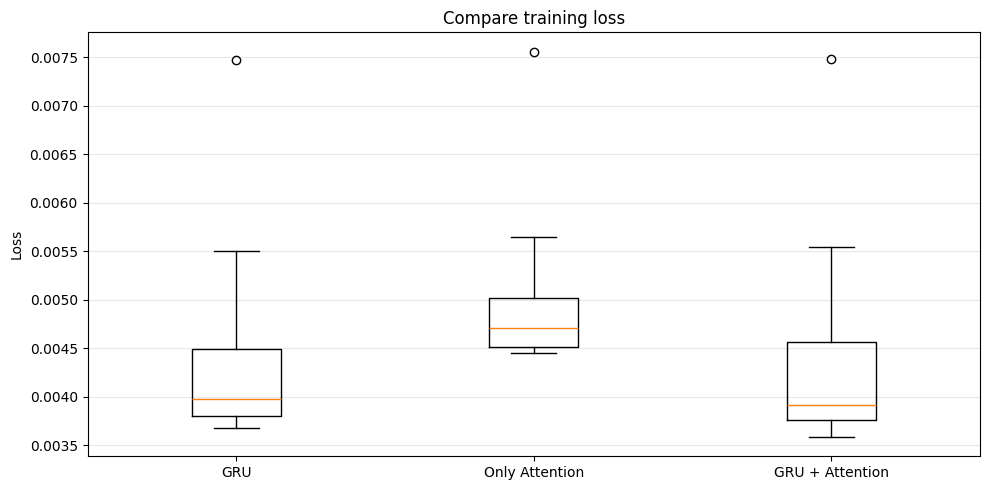

In [40]:
# Create single boxplot for train and validation loss
plt.figure(figsize=(10, 5))

# Boxplot with both train and val loss
data_to_plot = [df_gru['train_loss'], df_only_attention['train_loss'], df_gru_and_attention['train_loss']]
plt.boxplot(data_to_plot, labels=['GRU', 'Only Attention', 'GRU + Attention'])  # 3 labely pre 3 boxploty
plt.ylabel('Loss')
plt.title('Compare training loss')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_compare_training_loss.png', dpi=150)
plt.show()

In [ ]:
# Create single boxplot for train and validation loss
plt.figure(figsize=(10, 5))

# Boxplot with both train and val loss
data_to_plot = [df_gru['val_loss'], df_only_attention['val_loss'], df_gru_and_attention['val_loss']]
plt.boxplot(data_to_plot, labels=['GRU', 'Only Attention', 'GRU + Attention'])  # 3 labely pre 3 boxploty
plt.ylabel('Loss')
plt.title('Compare validation loss')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_compare_validation_loss.png', dpi=150)
plt.show()

/var/folders/rd/hbs43jr914scc2rt6syn712h0000gn/T/ipykernel_57732/4200958795.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_gru['val_loss']], labels=['GRU'])
